# Trinet embedded metadata (TMF) & calibration — end-to-end example

Every Trinet recording is **self-contained**: the MP4 you copy off the camera
carries, inside the file itself,

- the full **IMU stream** (accel / gyro / magnetometer, 400 Hz),
- **per-frame timing** (start-of-frame timestamps on the IMU clock, exposure),
- **thermal telemetry** (1 Hz device temperature),
- a **recording-metadata** JSON (device ID, firmware, frame-drop summary, …),
- and the camera's stored **calibration** (intrinsics, extrinsics, IMU noise
  model) — if one has been uploaded to the device.

So a single `.mp4` is enough to run camera–IMU pipelines: no sidecar files to
keep track of, nothing to lose. (The camera *also* writes `.imu`/`.vts`/`.tel`
sidecars next to the MP4 for convenience — they are byte-identical to what is
embedded.)

This notebook walks the whole path on a real recording included in this repo
(`examples/data/take0002_L.mp4`, the left eye of a stereo take, recorded while
the camera was being waved and rotated by hand):

1. read the embedded metadata and understand what's in it,
2. get the IMU and per-frame timing as NumPy arrays and plot them,
3. decode the embedded **calibration blob** and use it to undistort a frame.

The byte-level format is specified in [`docs/data_formats.md`](../docs/data_formats.md)
(section *Embedded metadata track (TMF)*).

In [1]:
from pathlib import Path
import json, struct, sys

import numpy as np
import matplotlib.pyplot as plt

# Make the `trinet_tools` package importable without a pip install: walk up
# from the working dir to the repo root (the folder that contains trinet_tools/).
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "trinet_tools" / "__init__.py").exists():
        sys.path.insert(0, str(_p))
        REPO = _p
        break

from trinet_tools import calib_blob
from trinet_tools.tmf import read_tmf
from trinet_tools.reader import read_imu, read_vts

VIDEO = REPO / "examples" / "data" / "take0002_L.mp4"
OUT = REPO / "examples" / "out"
OUT.mkdir(exist_ok=True)
print(VIDEO, f"{VIDEO.stat().st_size/1e6:.1f} MB")

/home/goldenrishabh/Documents/PanoculonLabs/PanoculonLabs/Trinet/Trinet-Tools/examples/data/take0002_L.mp4 38.9 MB


## 1. Read the embedded metadata

`read_tmf()` scans the MP4's boxes without touching the video stream. The
metadata lives in two places:

- a **`tmfd` timed metadata track** — one sample per second of recording, each
  a little-endian KLV (key–length–value) block holding that second's IMU
  samples, frame-timing entries and thermal record (GoPro-GPMF-style layout,
  fully specified in `docs/data_formats.md`);
- two **`moov/udta` boxes** — `tmfm` (a small JSON: device identity, frame-drop
  summary, thermal envelope) and `tmfc` (the calibration blob, verbatim).

Because the data rides in a proper MP4 track, ordinary players simply ignore
it, and the file survives copying/renaming like any other MP4.

In [2]:
rec = read_tmf(VIDEO)
print(f"TMF chunks   : {rec.chunk_count} (one per second of recording)")
print(f"IMU samples  : {rec.imu_sample_count}")
print(f"frame entries: {rec.vts_entry_count}")
print(f"thermal recs : {rec.tel_record_count}")
print(f"calibration  : {len(rec.calib_blob or b'')} bytes")
print()
print(json.dumps(rec.meta, indent=2))

TMF chunks   : 43 (one per second of recording)
IMU samples  : 15793
frame entries: 1167
thermal recs : 43
calibration  : 300 bytes

{
  "tmf_schema": 1,
  "device_id": "0a887a18b9928253f80483a6b3b21c29",
  "fw_version": "0.2.1",
  "hw_generation": "v5",
  "eye": "L",
  "pair_file": "take0002_R.mp4",
  "codec": "h265",
  "imu_version": 5,
  "imu_rate_hz": 400,
  "vts_version": 4,
  "sync": {
    "offset_ns": 0,
    "skew_ppb": 0,
    "quality_us": 0,
    "flags": 0
  },
  "drops": {
    "nominal_ms": 33.33,
    "expected": 1169,
    "recorded": 1167,
    "gap_count": 0,
    "gaps": []
  },
  "thermal": {
    "min_c": 39.9,
    "max_c": 56.5,
    "samples": 43
  },
  "generator": "trinet-mp4-finalize"
}


Reading the `tmfm` JSON above, the interesting fields:

- **`device_id`** — stable, anonymous ID of the exact camera that recorded
  this file (also the camera's USB serial). Ties a file to a device without
  exposing anything else about it.
- **`eye` / `pair_file`** — this is the **L** (scene-left) eye of a stereo
  pair; the sibling file named in `pair_file` holds the right eye. Both eyes
  embed the *same* IMU and calibration, so one file suffices for this demo.
- **`drops`** — the camera's own frame-continuity verdict. `gap_count: 0`
  means no frame was lost anywhere in the take; if frames *had* been dropped
  you'd get the exact position and length of every gap, so downstream tools
  never have to guess from timestamps.
- **`thermal`** — min/max device temperature over the take (full 1 Hz series
  is in the track, plotted below).
- **`imu_rate_hz`, `imu_version`, `vts_version`** — format/rate info for the
  embedded streams.

## 2. IMU and frame timing as NumPy arrays

The embedded streams reconstruct the camera's sidecar files **byte-identically**
(`imu_bytes()` / `vts_bytes()` / `tel_bytes()`), so the regular sidecar readers
in `trinet_tools.reader` work on them directly — same code path whether your
data came from sidecars or from inside the MP4.

IMU: 15793 samples @ 399.3 Hz, |accel| mean 9.69 m/s^2


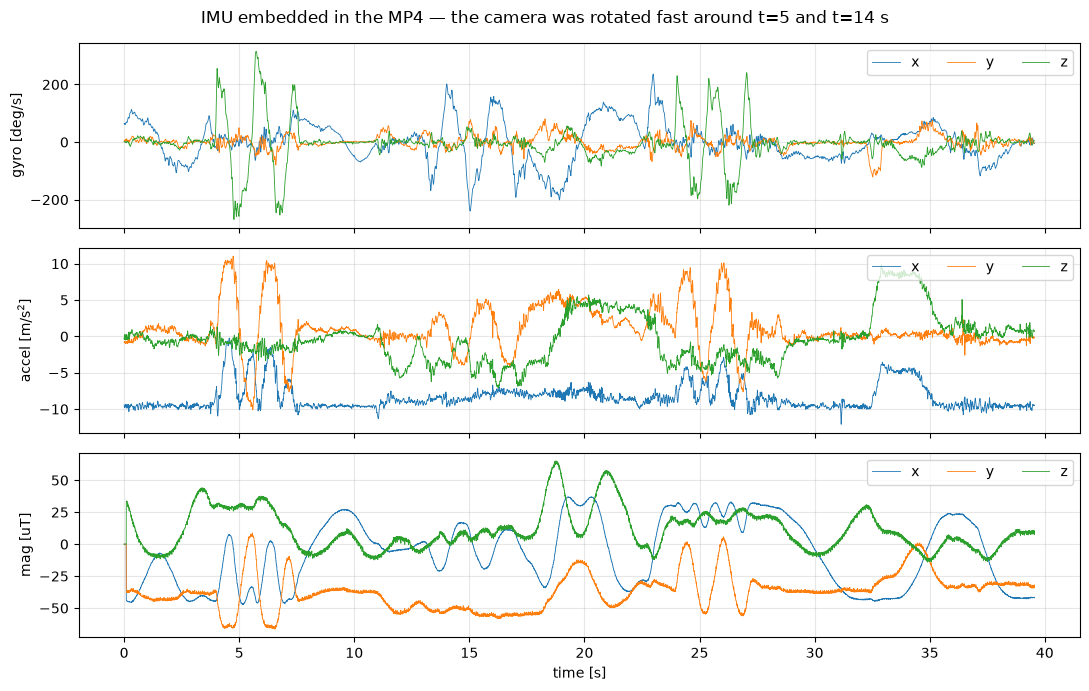

In [3]:
stem = VIDEO.stem
(OUT / f"{stem}.imu").write_bytes(rec.imu_bytes())
(OUT / f"{stem}.vts").write_bytes(rec.vts_bytes())

imu = read_imu(str(OUT / f"{stem}.imu"))
vts = read_vts(str(OUT / f"{stem}.vts"))

t_imu = (imu.timestamps_ns - imu.timestamps_ns[0]) / 1e9
rate = 1e9 / np.diff(imu.timestamps_ns.astype(np.int64)).mean()
print(f"IMU: {len(t_imu)} samples @ {rate:.1f} Hz, "
      f"|accel| mean {np.linalg.norm(imu.accel, axis=1).mean():.2f} m/s^2")

fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for a, lbl in enumerate("xyz"):
    ax[0].plot(t_imu, np.degrees(imu.gyro[:, a]), lw=0.6, label=lbl)
    ax[1].plot(t_imu, imu.accel[:, a], lw=0.6, label=lbl)
    ax[2].plot(t_imu, imu.mag[:, a], lw=0.6, label=lbl)
ax[0].set_ylabel("gyro [deg/s]"); ax[1].set_ylabel("accel [m/s$^2$]")
ax[2].set_ylabel("mag [uT]"); ax[2].set_xlabel("time [s]")
for a_ in ax: a_.legend(loc="upper right", ncol=3); a_.grid(alpha=0.3)
fig.suptitle("IMU embedded in the MP4 — the camera was rotated fast around t=5 and t=14 s")
plt.tight_layout(); plt.show()

### Per-frame timing

Each video frame has an entry on the **same clock as the IMU**:

- **`sof_timestamps_ns`** — the frame's reference timestamp. On this firmware
  (`vts_version` 4 with the `FRAME_CENTERED` flag) it is the **mid-exposure
  instant of the middle image row** — exactly the timestamp you want to hand
  to a VIO/SLAM pipeline or to Kalibr.
- **`exposure_us`** — per-frame exposure time.
- **`timing_flags`** — how the timestamp was derived (see `docs/data_formats.md`).

Two things worth plotting: the frame interval (uniform = no drops, agreeing
with the `drops` summary), and the exposure (the camera holds exposure on the
mains flicker-free grid, so indoor lighting doesn't beat against the frame
rate).

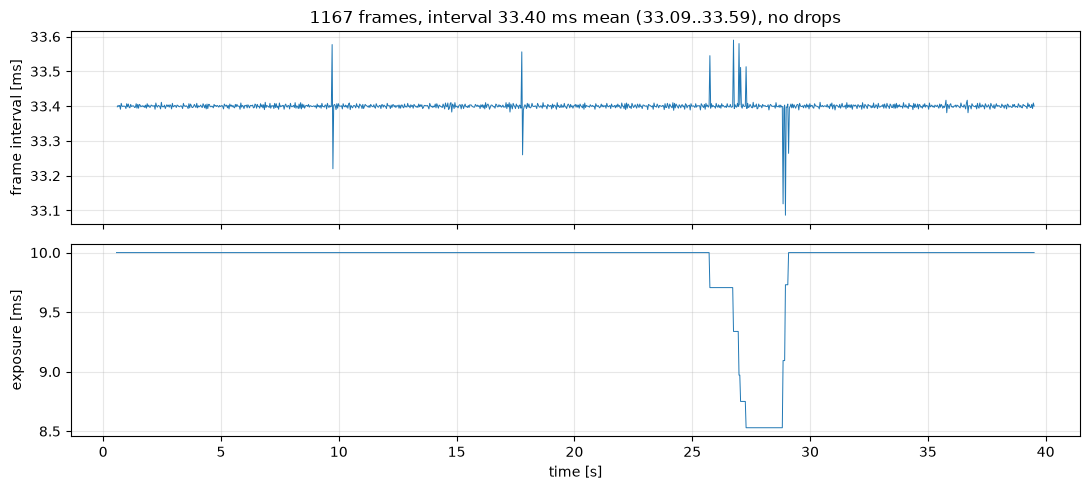

IMU covers video: starts 565 ms before frame 0, ends 43 ms after last frame


In [4]:
sof = vts.sof_timestamps_ns.astype(np.int64)
t_frame = (sof - imu.timestamps_ns[0].astype(np.int64)) / 1e9
dt_ms = np.diff(sof) / 1e6

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t_frame[1:], dt_ms, lw=0.7)
ax[0].set_ylabel("frame interval [ms]"); ax[0].grid(alpha=0.3)
ax[0].set_title(f"{len(sof)} frames, interval {dt_ms.mean():.2f} ms mean "
                f"({dt_ms.min():.2f}..{dt_ms.max():.2f}), no drops")
ax[1].plot(t_frame, vts.exposure_us / 1000.0, lw=0.7)
ax[1].set_ylabel("exposure [ms]"); ax[1].set_xlabel("time [s]"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"IMU covers video: starts {(sof[0]-imu.timestamps_ns[0].astype(np.int64))/1e6:.0f} ms "
      f"before frame 0, ends {(imu.timestamps_ns[-1].astype(np.int64)-sof[-1])/1e6:.0f} ms after last frame")

### Thermal telemetry

One record per second: device temperature plus the camera's operating point
(CPU frequency, configured bitrate/framerate, thermal-management state).

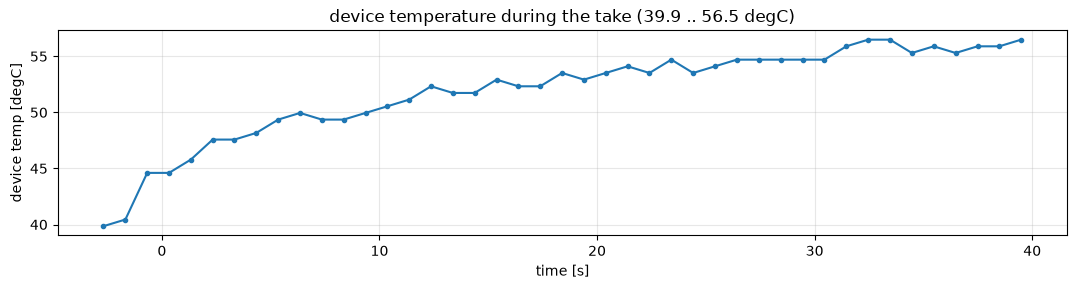

In [5]:
tel = np.frombuffer(rec.tel_records, dtype=np.dtype([
    ("ts_ns", "<u8"), ("temp_mc", "<i4"), ("cpu_khz", "<u4"),
    ("bitrate_kbps", "<u4"), ("fps", "<u2"), ("thermal_state", "u1"),
    ("led_state", "u1")]))
t_tel = (tel["ts_ns"].astype(np.int64) - imu.timestamps_ns[0].astype(np.int64)) / 1e9
plt.figure(figsize=(11, 3))
plt.plot(t_tel, tel["temp_mc"] / 1000.0, marker=".")
plt.ylabel("device temp [degC]"); plt.xlabel("time [s]"); plt.grid(alpha=0.3)
plt.title(f"device temperature during the take "
          f"({tel['temp_mc'].min()/1000:.1f} .. {tel['temp_mc'].max()/1000:.1f} degC)")
plt.tight_layout(); plt.show()

## 3. The embedded calibration

If a calibration has been uploaded to the camera (over USB or from the Trinet
app), every subsequent recording embeds it verbatim in the `tmfc` box — the
file itself tells you how to interpret its pixels and where the IMU sits.

The blob is the compact binary **TBLC** format (`trinet_tools/calib_blob.py`
is the reference decoder; CRC-protected). This camera is a stereo unit, so we
get the **v2 stereo layout**:

- `cameras[0]` / `cameras[1]` — intrinsics for the scene-**left** (`_L`) and
  scene-**right** (`_R`) eye: image size, projection model, `fx fy cx cy`,
  distortion coefficients, per-camera IMU time offset, calibration quality;
- `T_cam0_imu` — 4x4 transform taking IMU-frame points to the left camera
  frame;
- `T_cam1_cam0` — the stereo extrinsic (right camera w.r.t. left); its
  translation is the baseline;
- a shared IMU block: noise densities / random walks (the values you put in a
  Kalibr/VIO config) and calibration-time biases.

`timeshift` sign convention: `t_imu = t_cam + timeshift_cam_imu_s`.

In [6]:
calib = calib_blob.unpack(rec.calib_blob)
(OUT / f"{stem}.calibration.json").write_text(json.dumps(calib, indent=2))

for i, cam in enumerate(calib["cameras"]):
    it = cam["intrinsics"]
    print(f"cam{i} ({'scene-left' if i == 0 else 'scene-right'}): "
          f"{it['image_size'][0]}x{it['image_size'][1]} {it['model']}  "
          f"fx={it['fx']:.1f} fy={it['fy']:.1f} cx={it['cx']:.1f} cy={it['cy']:.1f}")
    print(f"      distortion {np.round(it['distortion'], 4).tolist()}  "
          f"timeshift {cam['timeshift_cam_imu_s']*1e3:+.2f} ms  "
          f"reproj rms {cam.get('reprojection_rms_px', 0):.2f} px")

t = np.array(calib["T_cam1_cam0"])[:3, 3]
print(f"\nstereo baseline: t = {np.round(t*1e3, 2).tolist()} mm  "
      f"(|t| = {np.linalg.norm(t)*1e3:.2f} mm)")
print("IMU noise model (Kalibr/VIO config values):")
for k, v in calib["imu"]["noise_model"].items():
    print(f"  {k:22s} {v:.3g}")

cam0 (scene-left): 1920x1080 equidistant  fx=587.8 fy=592.2 cx=897.1 cy=603.5
      distortion [0.1392, 0.063, -0.0758, 0.0158]  timeshift +9.90 ms  reproj rms 1.42 px
cam1 (scene-right): 1920x1080 equidistant  fx=590.1 fy=593.9 cx=876.8 cy=547.1
      distortion [0.1449, 0.0556, -0.0739, 0.016]  timeshift +8.92 ms  reproj rms 1.49 px

stereo baseline: t = [-70.31, 0.44, 0.79] mm  (|t| = 70.31 mm)
IMU noise model (Kalibr/VIO config values):
  accel_noise_density    0.0102
  gyro_noise_density     0.0028
  accel_random_walk      0.00052
  gyro_random_walk       3.8e-05


### Use it: undistort a frame

The eyes are ~200-degree fisheye lenses with an equidistant model — OpenCV's
`cv2.fisheye` consumes the intrinsics exactly as stored. As a minimal "the
numbers are real" demo, undistort one frame of this very video with the
calibration that came embedded in it.

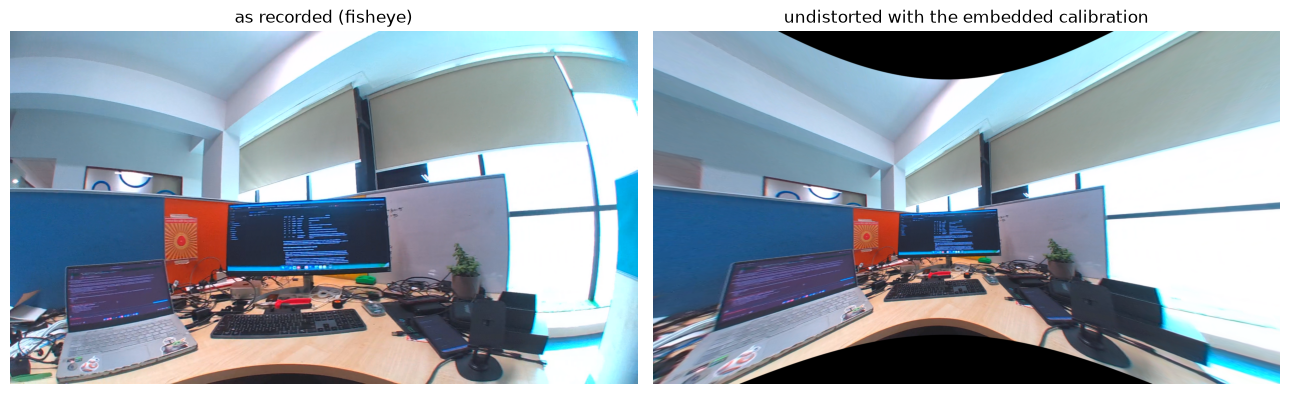

In [7]:
import cv2

cap = cv2.VideoCapture(str(VIDEO))
cap.set(cv2.CAP_PROP_POS_FRAMES, 260)          # a quiet moment of the take
ok, frame = cap.read(); cap.release()

it = calib["cameras"][0]["intrinsics"]         # this file is the left eye
K = np.array([[it["fx"], 0, it["cx"]], [0, it["fy"], it["cy"]], [0, 0, 1]])
D = np.array(it["distortion"][:4]).reshape(-1, 1)
newK = K.copy(); newK[0, 0] *= 0.6; newK[1, 1] *= 0.6   # zoom out to keep FOV
und = cv2.fisheye.undistortImage(frame, K, D, Knew=newK)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title("as recorded (fisheye)")
ax[1].imshow(cv2.cvtColor(und, cv2.COLOR_BGR2RGB)); ax[1].set_title("undistorted with the embedded calibration")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## Where to go from here

- **Camera-IMU fusion**: `trinet_tools.reader.interpolate_imu_to_frames(imu, vts)`
  resamples the IMU at every frame's timestamp — see the companion notebook
  [`imu_cam_timesync.ipynb`](imu_cam_timesync.ipynb) for the full
  time-alignment story (timestamps, timeshift, per-row timing).
- **Stereo**: the sibling `_R.mp4` named in `pair_file` is frame-synchronized
  with this file to a few microseconds; `T_cam1_cam0` from the embedded
  calibration rectifies the pair for stereo depth.
- **CLI**: everything here is also available without Python code —
  `python3 -m trinet_tools.tmf info  <file.mp4>` and
  `python3 -m trinet_tools.tmf extract <file.mp4>` recreate the sidecars and
  calibration from any Trinet MP4.
- **Format spec**: [`docs/data_formats.md`](../docs/data_formats.md).